In [1]:
# Install required libraries

!pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# IMPORT REQUIRED LIBRARIES

# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")



In [10]:
# LOAD DATASET

# Read CSV file
df = pd.read_csv(r'C:\Users\Muskan Rathore\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Show first 5 rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [11]:
# BASIC DATA UNDERSTANDING

# Shape of dataset
print("Rows and Columns:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Basic statistics
print("\nStatistical Summary:")
print(df.describe())

Rows and Columns: (1470, 35)

Columns:
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

Data Types:
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
Ed

In [12]:
# ATTRITION DISTRIBUTION

# Count attrition values
print(df['Attrition'].value_counts())

# Percentage
print(df['Attrition'].value_counts(normalize=True) * 100)

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


Attrition                      No        Yes
Department                                  
Human Resources         80.952381  19.047619
Research & Development  86.160250  13.839750
Sales                   79.372197  20.627803


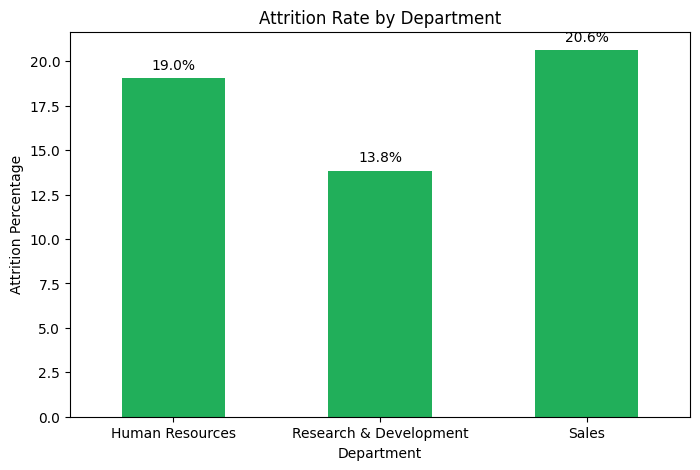

In [15]:
# ATTRITION RATE BY DEPARTMENT

# Create attrition percentage table
department_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100

print(department_attrition)

# Create plot
ax = department_attrition['Yes'].plot(
    kind='bar',
    figsize=(8,5),
    color="#21AF5A"   # Pastel Green Color
)

# Add data labels on bars
for i, value in enumerate(department_attrition['Yes']):
    ax.text(
        i,                  # X position
        value + 0.5,        # Y position
        f'{value:.1f}%',    # Label text
        ha='center',
        fontsize=10
    )

# Chart formatting
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Percentage")
plt.xlabel("Department")
plt.xticks(rotation=0)

# Show chart
plt.show()

Attrition                         No        Yes
JobRole                                        
Healthcare Representative  93.129771   6.870229
Human Resources            76.923077  23.076923
Laboratory Technician      76.061776  23.938224
Manager                    95.098039   4.901961
Manufacturing Director     93.103448   6.896552
Research Director          97.500000   2.500000
Research Scientist         83.904110  16.095890
Sales Executive            82.515337  17.484663
Sales Representative       60.240964  39.759036


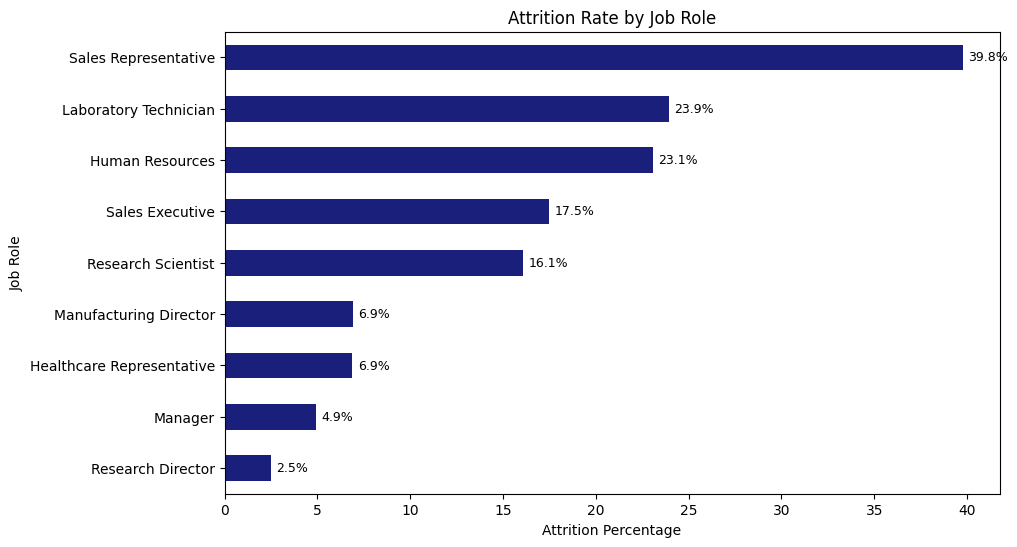

In [17]:
# ================================
# ATTRITION RATE BY JOB ROLE
# ================================

# Create attrition table
jobrole_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
) * 100

print(jobrole_attrition)

# Sort values
jobrole_sorted = jobrole_attrition['Yes'].sort_values()

# Create plot
ax = jobrole_sorted.plot(
    kind='barh',
    figsize=(10,6),
    color="#191F7A"  
)

# Add data labels
for i, value in enumerate(jobrole_sorted):
    ax.text(
        value + 0.3,      # Slightly right of bar
        i,                # Y-axis position
        f'{value:.1f}%',  # Label text
        va='center',
        fontsize=9
    )

# Chart formatting
plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Percentage")
plt.ylabel("Job Role")

# Show chart
plt.show()

In [19]:
# ================================
# CREATE TENURE BAND
# ================================

# Create tenure categories
df['TenureBand'] = pd.cut(
    df['YearsAtCompany'],
    bins=[0,2,5,10,40],
    labels=['0-2 Years','3-5 Years','6-10 Years','10+ Years']
)

# Check output
print(df[['YearsAtCompany', 'TenureBand']].head())

   YearsAtCompany  TenureBand
0               6  6-10 Years
1              10  6-10 Years
2               0         NaN
3               8  6-10 Years
4               2   0-2 Years


Attrition          No        Yes
TenureBand                      
0-2 Years   71.140940  28.859060
3-5 Years   86.175115  13.824885
6-10 Years  87.723214  12.276786
10+ Years   91.869919   8.130081


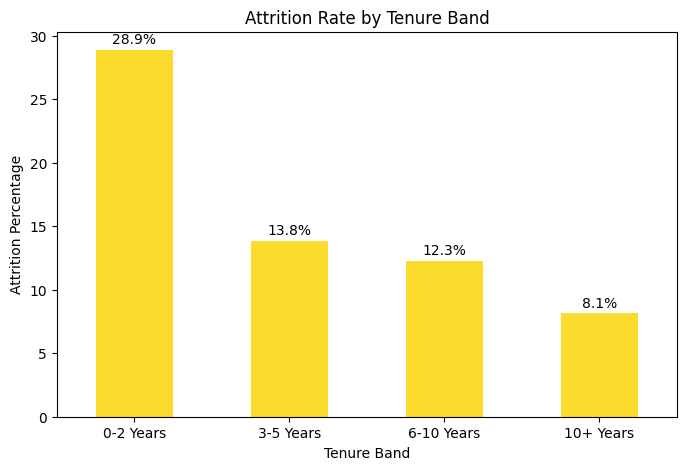

In [20]:
# ATTRITION BY TENURE BAND

# Create attrition table
tenure_attrition = pd.crosstab(
    df['TenureBand'],
    df['Attrition'],
    normalize='index'
) * 100

print(tenure_attrition)

# Create plot
ax = tenure_attrition['Yes'].plot(
    kind='bar',
    figsize=(8,5),
    color="#FBD606D7"   # Pastel Green Color
)

# Add data labels
for i, value in enumerate(tenure_attrition['Yes']):
    ax.text(
        i,                  # X position
        value + 0.5,        # Slightly above bar
        f'{value:.1f}%',    # Label text
        ha='center',
        fontsize=10
    )

# Chart formatting
plt.title("Attrition Rate by Tenure Band")
plt.ylabel("Attrition Percentage")
plt.xlabel("Tenure Band")
plt.xticks(rotation=0)

# Show chart
plt.show()

In [21]:
# CREATE SALARY BAND

df['SalaryBand'] = pd.cut(
    df['MonthlyIncome'],
    bins=[0,3000,6000,10000,25000],
    labels=['<3K','3K-6K','6K-10K','10K+']
)

print(df[['MonthlyIncome','SalaryBand']].head())

   MonthlyIncome SalaryBand
0           5993      3K-6K
1           5130      3K-6K
2           2090        <3K
3           2909        <3K
4           3468      3K-6K


Attrition          No        Yes
SalaryBand                      
<3K         71.392405  28.607595
3K-6K       87.283237  12.716763
6K-10K      88.000000  12.000000
10K+        91.103203   8.896797


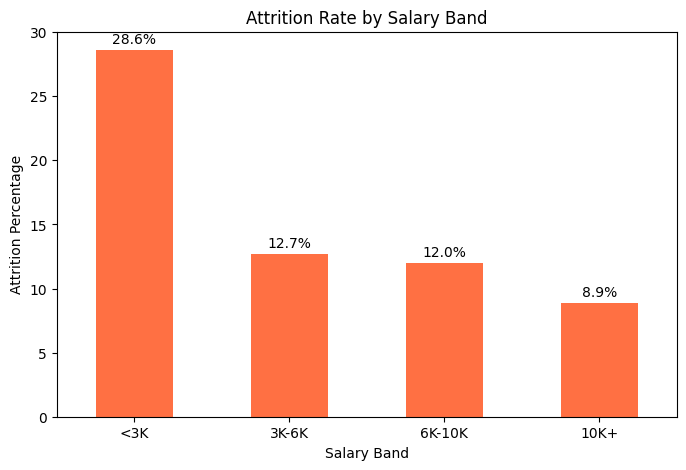

In [22]:
# ATTRITION BY SALARY BAND

# Create attrition table
salary_attrition = pd.crosstab(
    df['SalaryBand'],
    df['Attrition'],
    normalize='index'
) * 100

print(salary_attrition)

# Create plot
ax = salary_attrition['Yes'].plot(
    kind='bar',
    figsize=(8,5),
    color='#FF7043'   # Reddish Orange Color
)

# Add data labels
for i, value in enumerate(salary_attrition['Yes']):
    ax.text(
        i,                  # X position
        value + 0.5,        # Slightly above bar
        f'{value:.1f}%',    # Label text
        ha='center',
        fontsize=10
    )

# Chart formatting
plt.title("Attrition Rate by Salary Band")
plt.ylabel("Attrition Percentage")
plt.xlabel("Salary Band")
plt.xticks(rotation=0)

# Show chart
plt.show()

In [23]:
# TENURE RISK SCORE

# Employees with less than 2 years are risky
df['tenure_risk_score'] = np.where(
    df['YearsAtCompany'] < 2,
    1,
    0
)

print(df[['YearsAtCompany','tenure_risk_score']].head())

   YearsAtCompany  tenure_risk_score
0               6                  0
1              10                  0
2               0                  1
3               8                  0
4               2                  0


In [24]:
# OVERTIME FLAG

df['overtime_flag'] = np.where(
    df['OverTime'] == 'Yes',
    1,
    0
)

print(df[['OverTime','overtime_flag']].head())

  OverTime  overtime_flag
0      Yes              1
1       No              0
2      Yes              1
3      Yes              1
4       No              0


In [25]:
# SALARY GAP

# Median salary by Job Role
median_salary = df.groupby('JobRole')['MonthlyIncome'].transform('median')

# Difference between employee salary and role median
df['salary_gap'] = df['MonthlyIncome'] - median_salary

print(df[['JobRole','MonthlyIncome','salary_gap']].head())

                 JobRole  MonthlyIncome  salary_gap
0        Sales Executive           5993      -238.0
1     Research Scientist           5130      2242.5
2  Laboratory Technician           2090      -796.0
3     Research Scientist           2909        21.5
4  Laboratory Technician           3468       582.0


In [26]:
# MANAGER TENURE RATIO

df['manager_tenure_ratio'] = (
    df['YearsWithCurrManager'] /
    (df['YearsAtCompany'] + 1)
)

print(df[['YearsWithCurrManager',
          'YearsAtCompany',
          'manager_tenure_ratio']].head())

   YearsWithCurrManager  YearsAtCompany  manager_tenure_ratio
0                     5               6              0.714286
1                     7              10              0.636364
2                     0               0              0.000000
3                     0               8              0.000000
4                     2               2              0.666667


In [27]:
# CONVERT ATTRITION TO NUMERIC

df['Attrition'] = df['Attrition'].map({
    'Yes': 1,
    'No': 0
})

print(df['Attrition'].head())

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64


In [28]:
# TRAIN TEST SPLIT

# Features
X = df.drop('Attrition', axis=1)

# Target
y = df['Attrition']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check shapes
print("X Train Shape:", X_train.shape)
print("X Test Shape:", X_test.shape)

X Train Shape: (1176, 40)
X Test Shape: (294, 40)


In [31]:
# SAVE FINAL DATASET

df.to_csv("output/hr_attrition_feature_engineered.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully
